# Голосовой ассистент — классификация команд

Пайплайн: микрофон → VAD → MFCC → CNN → команда в консоль

**Что исправлено по сравнению с оригиналом:**
- Нормализация MFCC (StandardScaler по обучающим данным)
- Правильный train/val split + shuffle
- Батчевое обучение через DataLoader
- Динамический расчёт размера линейного слоя (нет хардкода)
- VAD на инференсе — распознаём только когда есть речь
- Нормализация амплитуды аудио перед MFCC
- Delta и Delta-Delta признаки (стандартная практика для команд)
- Dropout против переобучения

## 0. Импорты и константы

In [1]:
import os
import queue
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import sounddevice as sd

# ── Константы ────────────────────────────────────────────
SAMPLE_RATE   = 16000
N_MFCC        = 40
MAX_FRAMES    = 100   # ~1 сек речи при hop_length=160
BLOCK_SIZE    = 800   # 50 мс на чанк — как в игре (было 1600→зависало)
VAD_THRESHOLD = 0.01  # порог RMS для детектора тишины
MODEL_PATH  = "models/best_model.pt"
SCALER_PATH = "models/scaler.pkl"

LABELS   = {"go": 0, "stop": 1, "left": 2, "right": 3, "noise": 4}
COMMANDS = ["go", "stop", "left", "right", "noise"]

# Отдельный порог уверенности для каждой команды — как в игре
# «noise» = 1.0 означает «никогда не принимай как команду»
COMMAND_THRESHOLDS = {
    "go":    0.55,
    "stop":  0.90,
    "left":  0.58,
    "right": 0.66,
    "noise": 1.00,
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")


Устройство: cpu


## 1. Извлечение признаков

Используем MFCC + delta + delta-delta — это стандарт для классификации коротких команд.
Delta улавливает *скорость изменения* признаков (как звук меняется),
delta-delta — *ускорение*. Итого 40×3 = 120 признаков на фрейм.

In [2]:
def extract_features(audio: np.ndarray, sr: int = SAMPLE_RATE) -> np.ndarray:
    """
    Принимает numpy-массив float32 (уже загруженный или с микрофона).
    Возвращает матрицу признаков shape (3*N_MFCC, MAX_FRAMES).
    """
    # Нормализация амплитуды — критично для стабильности между файлами и микрофоном
    audio = audio.flatten().astype(np.float32)
    peak = np.max(np.abs(audio))
    if peak > 1e-6:
        audio = audio / peak

    # MFCC
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC, hop_length=160)

    # Delta и delta-delta
    delta  = librosa.feature.delta(mfcc, order=1)
    delta2 = librosa.feature.delta(mfcc, order=2)

    # Склеиваем по оси признаков: (120, T)
    feat = np.concatenate([mfcc, delta, delta2], axis=0)

    # Выравниваем по длине: обрезаем или паддим нулями
    T = feat.shape[1]
    if T >= MAX_FRAMES:
        feat = feat[:, :MAX_FRAMES]
    else:
        feat = np.pad(feat, ((0, 0), (0, MAX_FRAMES - T)))

    return feat  # shape: (120, 100)

## 2. Загрузка датасета

Ожидаемая структура папок:
```
dataset/
  start/  *.wav
  stop/   *.wav
  left/   *.wav
  right/  *.wav
  noise/  *.wav
```

In [3]:
X_list, y_list = [], []

for label, idx in LABELS.items():
    folder = f"dataset/{label}"
    if not os.path.isdir(folder):
        print(f"[предупреждение] Папка {folder} не найдена, пропускаем")
        continue

    files = [f for f in os.listdir(folder) if f.endswith((".wav", ".flac", ".mp3"))]
    print(f"  {label}: {len(files)} файлов")

    for fname in files:
        path = os.path.join(folder, fname)
        try:
            audio, _ = librosa.load(path, sr=SAMPLE_RATE)
            feat = extract_features(audio)
            X_list.append(feat)
            y_list.append(idx)
        except Exception as e:
            print(f"    ошибка {fname}: {e}")

X = np.array(X_list, dtype=np.float32)  # (N, 120, 100)
y = np.array(y_list, dtype=np.int64)
print(f"\nИтого: X={X.shape}, y={y.shape}")

  go: 3941 файлов
  stop: 3983 файлов
  left: 3911 файлов
  right: 3889 файлов
  noise: 507 файлов

Итого: X=(16231, 120, 100), y=(16231,)


## 3. Нормализация признаков

StandardScaler считается только по train-данным
и применяется к val и инференсу. Без этого модель видит на инференсе масштаб,
который никогда не встречала при обучении.

In [4]:
# Train/val split со стратификацией и shuffle
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # равномерное распределение классов в обеих частях
)

# Нормализуем: разворачиваем в 2D, фитим, сворачиваем обратно
N_train, F, T = X_train.shape
scaler = StandardScaler()

X_train_2d = X_train.reshape(N_train, -1)          # (N_train, 120*100)
X_train_2d = scaler.fit_transform(X_train_2d)       # fit только на train!
X_train = X_train_2d.reshape(N_train, F, T)

N_val = X_val.shape[0]
X_val_2d = X_val.reshape(N_val, -1)
X_val_2d = scaler.transform(X_val_2d)               # transform — без fit
X_val = X_val_2d.reshape(N_val, F, T)

# Добавляем канал для CNN: (N, 1, 120, 100)
X_train = X_train[:, np.newaxis, :, :]
X_val   = X_val[:, np.newaxis, :, :]

print(f"Train: {X_train.shape}, Val: {X_val.shape}")

Train: (12984, 1, 120, 100), Val: (3247, 1, 120, 100)


In [5]:
import pickle

with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

## 4. Модель CNN

Ключевые исправления:
- `adaptive_avg_pool` вместо хардкода размера — модель сама считает размер
- BatchNorm после свёрточных слоёв — стабилизирует обучение
- Dropout(0.5) перед полносвязными слоями — против переобучения

In [6]:
class AudioCNN(nn.Module):
    def __init__(self, num_classes: int = 5):
        super().__init__()

        self.conv = nn.Sequential(
            # Блок 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Блок 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Блок 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        # AdaptiveAvgPool → всегда выход (128, 4, 4) независимо от входного размера
        self.pool = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


model = AudioCNN(num_classes=len(LABELS)).to(device)
print(model)
total = sum(p.numel() for p in model.parameters())
print(f"\nПараметров: {total:,}")

AudioCNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=2048, out_features=256, bias=True)
    (3): ReLU()
    (4): Dropout(p

## 5. Обучение

- DataLoader с shuffle — данные перемешиваются каждую эпоху
- Батчи по 32 вместо одного прохода по всему датасету
- ReduceLROnPlateau — снижает learning rate при стагнации val loss
- Сохранение лучшей модели по val accuracy

### Аугментация

In [7]:
def augment_mfcc(x: torch.Tensor) -> torch.Tensor:
    """
    x: (1, F, T) — один сэмпл.
    SpecAugment: time masking + frequency masking + gaussian noise.
    Работает на уже готовой MFCC-матрице в памяти — быстро, без пересчёта.
    """
    x = x.clone()
    _, F, T = x.shape

    # Time masking — глушим до 15% длины
    t_len = int(T * 0.15 * torch.rand(1).item())
    if t_len > 0:
        t0 = torch.randint(0, max(1, T - t_len), (1,)).item()
        x[:, :, t0:t0 + t_len] = 0.0

    # Frequency masking — глушим до 15% коэффициентов
    f_len = int(F * 0.15 * torch.rand(1).item())
    if f_len > 0:
        f0 = torch.randint(0, max(1, F - f_len), (1,)).item()
        x[:, f0:f0 + f_len, :] = 0.0

    # Gaussian noise
    x = x + torch.randn_like(x) * 0.05

    return x

### DataLoaders 

In [8]:
train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                         torch.tensor(y_train, dtype=torch.long))
val_ds   = TensorDataset(torch.tensor(X_val,   dtype=torch.float32),
                         torch.tensor(y_val,   dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

criterion = nn.CrossEntropyLoss()

### Определяем режим: с нуля или дообучение

In [9]:
import os

if os.path.exists(MODEL_PATH):
    print(f"Найден {MODEL_PATH} → режим ДООБУЧЕНИЯ (fine-tuning)")
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

    # Маленький lr чтобы не перезаписать выученное
    optimizer = optim.SGD(model.parameters(), lr=1e-4, momentum=0.9, weight_decay=1e-4)
    EPOCHS    = 5
    PATIENCE  = 2    # early stopping — стоп если нет улучшений N эпох
    USE_AUG   = True
    mode_label = "fine-tune"
else:
    print(f"{MODEL_PATH} не найден → режим ОБУЧЕНИЯ С НУЛЯ")
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    EPOCHS    = 10
    PATIENCE  = 3
    USE_AUG   = True
    mode_label = "from-scratch"

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

Найден models/best_model.pt → режим ДООБУЧЕНИЯ (fine-tuning)


### Цикл обучения

In [10]:
best_val_acc = 0.0
no_improve   = 0
history      = {"tr_loss": [], "val_loss": [], "val_acc": []}

print(f"Эпох: {EPOCHS}  |  Early stopping patience: {PATIENCE}  |  Аугментация: {USE_AUG}")
print("-" * 70)
for epoch in range(EPOCHS):
    # train
    model.train()
    tr_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        if USE_AUG:
            xb = torch.stack([augment_mfcc(xb[i]) for i in range(len(xb))])
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * len(xb)
    tr_loss /= len(train_ds)

    # val
    model.eval()
    correct = total = val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out      = model(xb)
            val_loss += criterion(out, yb).item() * len(xb)
            correct  += (out.argmax(1) == yb).sum().item()
            total    += len(xb)
    val_loss /= total
    val_acc   = correct / total
    scheduler.step()

    history["tr_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # сохраняем лучшую
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve   = 0
        torch.save(model.state_dict(), MODEL_PATH)
        tag = " ★"
    else:
        no_improve += 1
        tag = f" (−{no_improve}/{PATIENCE})"

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+1:3d} | tr={tr_loss:.4f} | val={val_loss:.4f}"
          f" | acc={val_acc:.3f} | lr={lr_now:.2e}{tag}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping на эпохе {epoch+1}.")
        break

print(f"\nЛучшая val accuracy [{mode_label}]: {best_val_acc:.3f}")
print(f"Модель сохранена → {MODEL_PATH}")

Эпох: 5  |  Early stopping patience: 2  |  Аугментация: True
----------------------------------------------------------------------
Epoch   1 | tr=0.5303 | val=0.3788 | acc=0.863 | lr=9.05e-05 ★
Epoch   2 | tr=0.5324 | val=0.3764 | acc=0.869 | lr=6.58e-05 ★
Epoch   3 | tr=0.5156 | val=0.3665 | acc=0.867 | lr=3.52e-05 (−1/2)
Epoch   4 | tr=0.5165 | val=0.3597 | acc=0.872 | lr=1.05e-05 ★
Epoch   5 | tr=0.5167 | val=0.3682 | acc=0.868 | lr=1.00e-06 (−1/2)

Лучшая val accuracy [fine-tune]: 0.872
Модель сохранена → models/best_model.pt


### Кривые обучения 

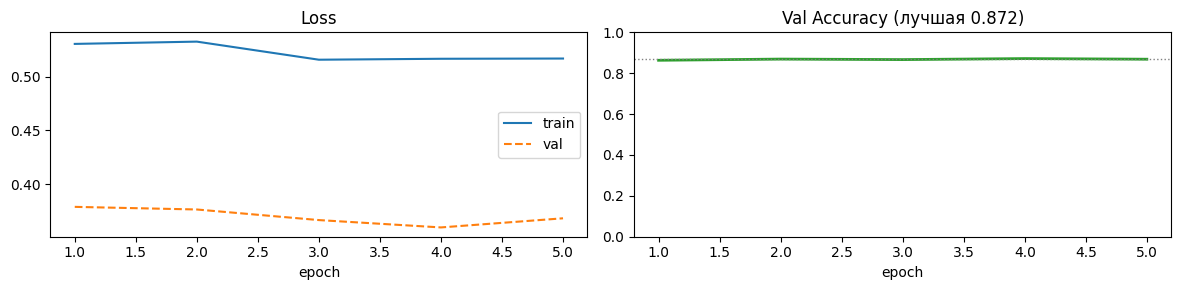

In [11]:
import matplotlib
matplotlib.rcParams["figure.dpi"] = 100
import matplotlib.pyplot as plt

ran = len(history["val_acc"])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3))
a1.plot(range(1, ran+1), history["tr_loss"],  label="train", lw=1.5)
a1.plot(range(1, ran+1), history["val_loss"], label="val",   lw=1.5, ls="--")
a1.set_title("Loss"); a1.legend(); a1.set_xlabel("epoch")
a2.plot(range(1, ran+1), history["val_acc"], color="tab:green", lw=2)
a2.axhline(best_val_acc, ls=":", color="gray", lw=1)
a2.set_title(f"Val Accuracy (лучшая {best_val_acc:.3f})")
a2.set_ylim(0, 1); a2.set_xlabel("epoch")
plt.tight_layout(); plt.show()

## 6. Загрузка лучшей модели

In [12]:
import pickle

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print(f"Модель загружена: {MODEL_PATH}")

with open(SCALER_PATH, "rb") as f:
    scaler = pickle.load(f)
print(f"Scaler загружен: {SCALER_PATH}")

Модель загружена: models/best_model.pt
Scaler загружен: models/scaler.pkl


## Отчёт валидации

Показывает precision/recall по каждой команде и матрицу ошибок.

              precision    recall  f1-score   support

          go      0.893     0.878     0.885       788
        stop      0.882     0.875     0.878       797
        left      0.829     0.854     0.841       782
       right      0.884     0.888     0.886       778
       noise      0.872     0.804     0.837       102

    accuracy                          0.872      3247
   macro avg      0.872     0.860     0.866      3247
weighted avg      0.872     0.872     0.872      3247



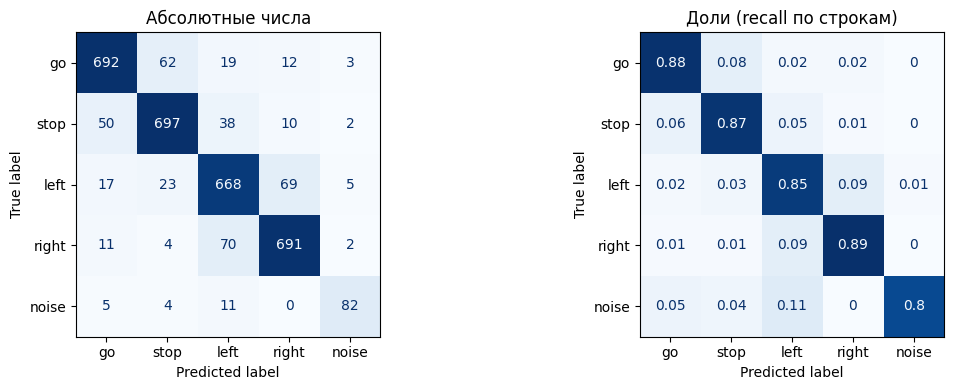

Топ ошибок:
  right    → left      ×70
  left     → right     ×69
  go       → stop      ×62
  stop     → go        ×50
  stop     → left      ×38
  left     → stop      ×23
  go       → left      ×19
  left     → go        ×17


In [13]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as _np

model.eval()
all_pred, all_true, all_conf = [], [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        probs = torch.softmax(model(xb), dim=1)
        preds = probs.argmax(1)
        all_pred.extend(preds.cpu().tolist())
        all_true.extend(yb.tolist())
        all_conf.extend(probs.max(1).values.cpu().tolist())

print(classification_report(all_true, all_pred, target_names=COMMANDS, digits=3))

cm = confusion_matrix(all_true, all_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(cm, display_labels=COMMANDS).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Абсолютные числа")
ConfusionMatrixDisplay(
    (cm.astype(float) / cm.sum(axis=1, keepdims=True)).round(2),
    display_labels=COMMANDS
).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Доли (recall по строкам)")
plt.tight_layout(); plt.show()

from collections import Counter
errors = [(COMMANDS[t], COMMANDS[p]) for t,p in zip(all_true,all_pred) if t!=p]
if errors:
    print("Топ ошибок:")
    for (t,p),n in Counter(errors).most_common(8):
        print(f"  {t:8s} → {p:8s}  ×{n}")
else:
    print("Ошибок нет!")


## 7. Инференс

Важно: применяем тот же scaler что при обучении.
Без этого модель получает другой масштаб признаков — и всегда предсказывает `noise`.

In [14]:
def predict(audio: np.ndarray):
    """
    Возвращает (индекс_класса, уверенность, np.array всех вероятностей).
    """
    feat = extract_features(audio)          # (120, 100)

    # Нормализация тем же scaler-ом что при обучении
    feat_2d = feat.reshape(1, -1)           # (1, 12000)
    feat_2d = scaler.transform(feat_2d)
    feat = feat_2d.reshape(1, 1, *feat.shape)  # (1, 1, 120, 100)

    x = torch.tensor(feat, dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = model(x)
        probs  = torch.softmax(logits, dim=1)[0]
        pred   = probs.argmax().item()
        conf   = probs[pred].item()

    return pred, conf, probs.cpu().numpy()  # <-- теперь возвращаем все вероятности


## 8. VAD — детектор голоса

Без VAD модель получает тишину и предсказывает `noise`.
С VAD — ждём пока появится речь, тогда собираем буфер и классифицируем.

In [15]:
import time as _time

# При BLOCK_SIZE=800 (50 мс/чанк):
MIN_SPEECH_CHUNKS = 2   # ≥ 100 мс речи — иначе шорох
SILENCE_LIMIT     = 8   # 8 × 50 мс = 400 мс тишины → конец фразы
MAX_SPEECH_CHUNKS = 30  # 30 × 50 мс = 1.5 сек максимум (защита от зависания)
COOLDOWN_SEC      = 0.8 # пауза после команды чтобы не ловить эхо


def is_speech(chunk: np.ndarray, threshold: float = VAD_THRESHOLD) -> bool:
    rms = np.sqrt(np.mean(chunk.flatten() ** 2))
    return rms > threshold


def collect_speech(q: queue.Queue) -> np.ndarray | None:
    """
    Конечный автомат: WAIT → SPEAKING → SILENCE.

    Исправлено:
      - двойной append chunk устранён (chunk не добавляется в ring_buf
        до проверки is_speech)
      - MAX_SPEECH_CHUNKS ограничивает длину — функция не зависает при
        постоянном фоновом шуме
      - SILENCE_LIMIT уменьшен до 8 × 50 мс = 400 мс (было 1.2 сек)
    """
    ring_buf   = []   # скользящее окно перед началом речи (pre-roll)
    speech_buf = []
    silent_cnt = 0
    speech_cnt = 0
    in_speech  = False

    while True:
        chunk = q.get()

        if not in_speech:
            # Поддерживаем скользящее окно из 2 чанков (100 мс pre-roll)
            ring_buf.append(chunk)
            if len(ring_buf) > 2:
                ring_buf.pop(0)

            if is_speech(chunk):
                in_speech  = True
                # ring_buf уже содержит текущий chunk — не добавляем повторно
                speech_buf = ring_buf.copy()
                speech_cnt = 1

        else:
            speech_buf.append(chunk)
            speech_cnt += 1

            if is_speech(chunk):
                silent_cnt = 0
            else:
                silent_cnt += 1
                if silent_cnt >= SILENCE_LIMIT:
                    if speech_cnt < MIN_SPEECH_CHUNKS:
                        return None   # слишком короткий — шорох
                    return np.concatenate(speech_buf, axis=0)

            # Защита от зависания при постоянном фоновом шуме
            if speech_cnt >= MAX_SPEECH_CHUNKS:
                return np.concatenate(speech_buf, axis=0)


def flush_queue(q: queue.Queue) -> None:
    while not q.empty():
        try: q.get_nowait()
        except queue.Empty: break


## 9. Запуск ассистента

Говорите команду → пауза → видите результат в консоли.
Прерывание: **Kernel → Interrupt**.

Вывод цветной (через ANSI-коды):
- 🟢 **зелёный** — команда принята (выше порога)
- 🟡 **жёлтый** — команда отклонена (ниже порога для этой команды)
- ⚪ **серый** — шум / слишком тихо

Строка `│ go … stop … left … right … noise │` показывает уверенность по каждому классу отдельно.


In [16]:
audio_q = queue.Queue()

def mic_callback(indata, frames, time, status):
    audio_q.put(indata.copy())


# ── ANSI цвета ──────────────────────────────────────────────────────────────
GREEN  = "\033[92m"
YELLOW = "\033[93m"
GRAY   = "\033[90m"
RESET  = "\033[0m"
BOLD   = "\033[1m"


def confidence_bar(probs: np.ndarray, winner_idx: int, accepted: bool) -> str:
    """
    Строка вида: │ go:55% stop:12% left:08% right:22% noise:03% │
    Победитель подсвечивается жирным, принятые команды — зелёным.
    """
    parts = []
    for i, (cmd, p) in enumerate(zip(COMMANDS, probs)):
        pct = f"{p:.0%}"
        tag = f"{cmd}:{pct}"
        if i == winner_idx:
            color = GREEN if accepted else YELLOW
            tag = f"{BOLD}{color}{tag}{RESET}"
        else:
            tag = f"{GRAY}{tag}{RESET}"
        parts.append(tag)
    return "│ " + "  ".join(parts) + " │"


print(f"{BOLD}Ассистент запущен.{RESET} Говорите: " +
      " / ".join(c for c in COMMANDS if c != "noise"))
print("Для выхода: Kernel → Interrupt")
print("-" * 60)

with sd.InputStream(samplerate=SAMPLE_RATE, channels=1,
                    blocksize=BLOCK_SIZE, callback=mic_callback):
    while True:
        audio = collect_speech(audio_q)
        if audio is None:
            continue

        pred, conf, all_probs = predict(audio)
        label     = COMMANDS[pred]
        threshold = COMMAND_THRESHOLDS.get(label, 0.7)
        accepted  = (label != "noise") and (conf >= threshold)

        bar = confidence_bar(all_probs, pred, accepted)

        if accepted:
            # Принятая команда
            print(f"{GREEN}{BOLD}>> {label.upper():<6}{RESET}"
                  f"  conf={conf:.0%}  порог={threshold:.0%}  {bar}")
        elif label == "noise":
            # Тихо выводим шум серым
            print(f"{GRAY}   {'шум':<6}  conf={conf:.0%}  {bar}{RESET}")
        else:
            # Команда есть, но ниже порога
            print(f"{YELLOW}   {label:<6}  conf={conf:.0%}  порог={threshold:.0%} ↓  {bar}{RESET}")

        flush_queue(audio_q)
        _time.sleep(COOLDOWN_SEC)
        flush_queue(audio_q)


Ассистент запущен. Говорите: go / stop / left / right
Для выхода: Kernel → Interrupt
------------------------------------------------------------
   шум     conf=68%  │ go:15%  stop:5%  left:8%  right:4%  noise:68% │
   шум     conf=51%  │ go:11%  stop:21%  left:14%  right:3%  noise:51% │
   go      conf=32%  порог=55% ↓  │ go:32%  stop:28%  left:10%  right:3%  noise:28% │
   шум     conf=42%  │ go:12%  stop:25%  left:15%  right:6%  noise:42% │
   шум     conf=54%  │ go:15%  stop:19%  left:10%  right:3%  noise:54% │
>> LEFT    conf=64%  порог=58%  │ go:1%  stop:1%  left:64%  right:34%  noise:0% │
>> RIGHT   conf=97%  порог=66%  │ go:0%  stop:0%  left:3%  right:97%  noise:0% │
   шум     conf=51%  │ go:10%  stop:19%  left:17%  right:3%  noise:51% │
   go      conf=41%  порог=55% ↓  │ go:41%  stop:33%  left:12%  right:5%  noise:9% │
   шум     conf=65%  │ go:15%  stop:11%  left:7%  right:2%  noise:65% │
   шум     conf=41%  │ go:10%  stop:24%  left:22%  right:4%  noise:41% │
   шум     c

KeyboardInterrupt: 